<a href="https://colab.research.google.com/github/JoshuaHanson69/lab-2-predictive-analytics/blob/main/lab_2_predictive_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: Predictive Analytics with Machine Learning

**Duration:** 2 weeks [18 Jun - 25 Jun, 2026]
**Due Date:** 25th June, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Joshua Elvis Ataa-Oko Hanson
**Student ID:** 27372028

---

### Objective

In this lab you will run a complete machine-learning workflow on **two real tabular datasets**,
covering both **supervised** and **unsupervised** learning:

| # | Task | Dataset | Type | Target |
|---|------|---------|------|--------|
| 1 | **Regression** | NYC Yellow Taxi trips | Supervised | `tip_amount` (continuous) |
| 2 | **Multi-class classification** | Obesity-level prediction | Supervised | `NObeyesdad` (7 classes) |
| 3 | **Clustering (K-Means)** | Obesity features (labels hidden) | Unsupervised | discover patient groups |

Along the way you will practise **NumPy, Pandas, and scikit-learn** to load and explore data,
clean and preprocess it, engineer features, split it into **train / validation / test** sets,
train models, **check for overfitting**, and discover hidden structure with clustering.

> **Note:** In this lab your *reasoning* is graded just as heavily as your *code*. Every section
> ends with a **Student Reasoning** box — fill it in with full sentences that justify your choices.

### Topics covered
Supervised learning (regression & classification), unsupervised learning (K-Means clustering),
feature engineering, train/validation/test splits, model evaluation, and overfitting.


---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-2-predictive-analytics` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_2_predictive_analytics.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas scikit-learn matplotlib seaborn`.
5. Commit and push your finished, fully-run notebook at the end.

**Local setup**
```bash
python -m venv .venv
source .venv/bin/activate        # Windows: .venv\Scripts\activate
pip install -r requirements.txt
jupyter lab
```

Open a new notebook, rename it, and run the cells below directly
(the datasets are loaded straight from their URLs, so no Drive mount is required).


In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"


---
# Section 1 — Supervised Learning: Regression
## Predicting taxi `tip_amount` (NYC Yellow Taxi)

Each row is a completed taxi trip. Your goal is to **predict the tip a passenger leaves**
(`tip_amount`, a continuous value) from the trip's characteristics. The available columns are:

`VendorID, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID,
DOLocationID, payment_type, fare_amount, mta_tax, tolls_amount, improvement_surcharge, tip_amount`


### Part 1.1 — Load and explore the taxi data
Understand the shape, the data types, missing values, and the distribution of the target.

(41202, 13)
   VendorID  passenger_count  trip_distance  RatecodeID  store_and_fwd_flag  \
0         2                1          17.63           2                   1   
1         2                1          19.52           2                   1   
2         2                1          17.81           2                   1   
3         2                2          19.30           2                   1   
4         2                1          18.75           2                   1   

   PULocationID  DOLocationID  payment_type  fare_amount  mta_tax  \
0           132           164             1         70.0      0.5   
1           132           236             1         70.0      0.5   
2           132            48             1         70.0      0.5   
3           132           148             1         70.0      0.5   
4           132           234             1         70.0      0.5   

   tolls_amount  improvement_surcharge  tip_amount  
0          6.94                      1       

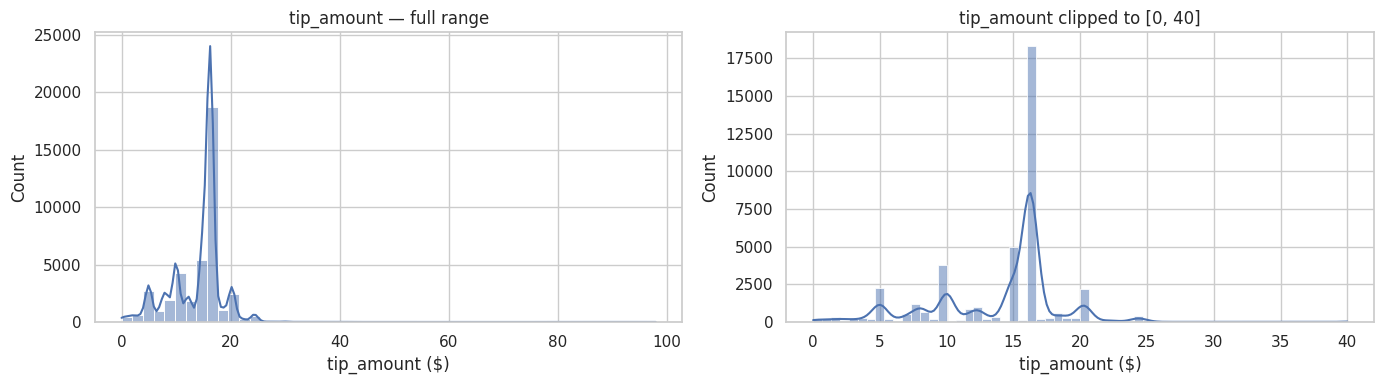

In [2]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
# taxi = pd.read_csv(...)
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
# - taxi.shape, taxi.head(), taxi.info()
# - taxi.describe()
# - count missing values per column: taxi.isna().sum()
print(taxi.shape)
print(taxi.head())
print(taxi.info())
print(taxi.describe())
print(taxi.isna().sum())

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(taxi['tip_amount'], bins=50, kde=True, ax=ax1)
ax1.set_title('tip_amount — full range')
ax1.set_xlabel('tip_amount ($)')

tip_zoomed = taxi['tip_amount'].clip(0, 40)
sns.histplot(tip_zoomed, bins=60, kde=True, ax=ax2)
ax2.set_title('tip_amount clipped to [0, 40]')
ax2.set_xlabel('tip_amount ($)')

plt.tight_layout()
plt.show()


**Student Reasoning — Taxi data exploration**
*What is the shape of the data? Are there missing values or impossible values
(e.g. negative tips, zero-distance trips)? What does the `tip_amount` distribution look like
(skew, outliers, many zeros)? How will this influence your preprocessing?*

> **Answer:** The dataset has 41,202 rows and 13 columns with no missing values. VendorID and payment_type are the same value for every row, so they will be dropped as they add no useful information. The tip_amount is mostly clustered around $16.19, with a big spike at that value suggesting it is a common default tip. There are a few very high tips up to $98 which are outliers. There are also 76 trips with a distance of 0 which are invalid and will be removed.


### Part 1.2 — Preprocessing & feature engineering
Clean the data and create features that help predict the tip.

In [3]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
taxi = taxi.dropna()
taxi = taxi[taxi['trip_distance'] > 0]
taxi = taxi[taxi['fare_amount'] > 0]
taxi = taxi[taxi['tip_amount'] >= 0]

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do notaxi['fare_per_mile'] = taxi['fare_amount'] / taxi['trip_distance']
taxi['fare_per_mile'] = taxi['fare_amount'] / taxi['trip_distance']
taxi['total_surcharges'] = taxi['mta_tax'] + taxi['tolls_amount'] + taxi['improvement_surcharge']
print("Shape after cleaning:", taxi.shape)

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).
taxi = pd.get_dummies(taxi, columns=['RatecodeID', 'store_and_fwd_flag'], drop_first=True)
# Dropping constant columns
taxi = taxi.drop(columns=['VendorID', 'payment_type'])
print(taxi.head())
print(taxi.columns.tolist())

# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)


Shape after cleaning: (41126, 15)
   passenger_count  trip_distance  PULocationID  DOLocationID  fare_amount  \
0                1          17.63           132           164         70.0   
1                1          19.52           132           236         70.0   
2                1          17.81           132            48         70.0   
3                2          19.30           132           148         70.0   
4                1          18.75           132           234         70.0   

   mta_tax  tolls_amount  improvement_surcharge  tip_amount  fare_per_mile  \
0      0.5          6.94                      1       16.54       3.970505   
1      0.5          6.94                      1       16.19       3.586066   
2      0.5          6.94                      1       12.00       3.930376   
3      0.5          0.00                      1        5.00       3.626943   
4      0.5          6.94                      1       10.00       3.733333   

   total_surcharges  Ratecod

**Student Reasoning — Taxi preprocessing**
*1. How did you handle missing/invalid rows and why?*
*2. Which new feature(s) did you engineer and what is the intuition behind them?*
*3. Which scaling method did you choose and why is it appropriate here?*

> **Answer:After checking the data, there were no missing values so no imputation was needed. I removed 76 rows where trip_distance was 0 since you can't have a real trip with no distance. There were no negative tip amounts so I kept all rows. I created two new features: fare_per_mile by dividing fare_amount by trip_distance, because I thought a more expensive trip per mile might lead to a higher tip, and total_surcharges by adding up mta_tax, tolls_amount and improvement_surcharge since extra charges on a trip might affect how much someone tips. I dropped VendorID and payment_type because they were the same value for every single row so they wouldn't help the model learn anything. RatecodeID and store_and_fwd_flag were encoded using get_dummies since they are categorical. I will apply the scaler in Part 1.3 after splitting the data to avoid leaking information from the test set into the training process.


### Part 1.3 — Train / Validation / Test split
A three-way split lets you tune on validation data and keep the test set as a final, unbiased check.

In [4]:
# TODO: Separate features (X) and target (y = tip_amount)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X = taxi.drop(columns=['tip_amount'])
y = taxi['tip_amount']

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE)

print("Train size:", X_train.shape)
print("Val size:", X_val.shape)
print("Test size:", X_test.shape)

# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling done!")

Train size: (24675, 14)
Val size: (8225, 14)
Test size: (8226, 14)
Scaling done!


**Student Reasoning — Splitting**
*What ratio did you use? Why is a separate validation set useful in addition to a test set?
Why must the scaler (and any imputation statistics) be fit on the training data only?*

> **Answer:I used a 60/20/20 split, giving me 24,675 training rows, 8,225 validation rows and 8,226 test rows. I split it this way because I needed enough data to train the model, but also enough held-out data to fairly evaluate it. The validation set is useful because it lets me test different models and tune them without touching the test set at all. The test set is only used at the very end to give a final unbiased score. I fit the scaler only on the training data because if I included the validation or test data, the scaler would have information about those sets before the model ever sees them, which would be cheating and give overly optimistic results. The same mean and standard deviation from the training set is then applied to transform the validation and test sets.


### Part 1.4 — Train a regressor and check for overfitting
Train a model and evaluate it on **train, validation, and test** sets.

=== Linear Regression ===
Train  RMSE: 4.8045  R2: 0.0513
Val    RMSE: 5.0371  R2: 0.0486
Test   RMSE: 5.0132  R2: 0.0511

=== Random Forest ===
Train  RMSE: 2.8363  R2: 0.6694
Val    RMSE: 5.6479  R2: -0.1961
Test   RMSE: 5.6093  R2: -0.1880


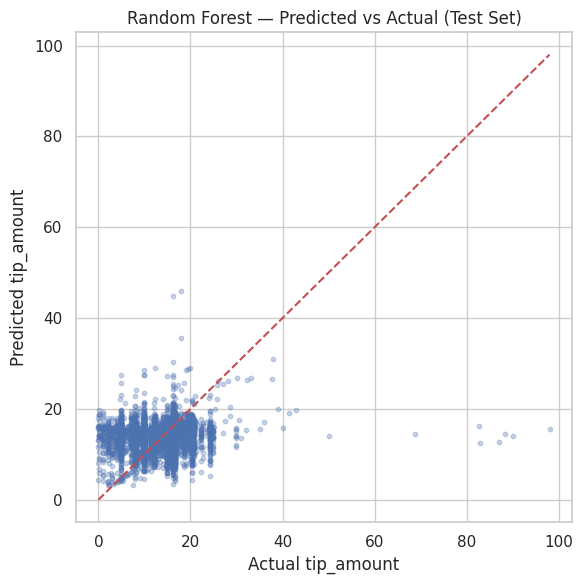

In [5]:
# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train_scaled, y_train)

# TODO: Predict on train, validation, and test sets.
lr_train_pred = lr.predict(X_train_scaled)
lr_val_pred = lr.predict(X_val_scaled)
lr_test_pred = lr.predict(X_test_scaled)
rf_train_pred = rf.predict(X_train_scaled)
rf_val_pred = rf.predict(X_val_scaled)
rf_test_pred = rf.predict(X_test_scaled)

# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)
print("=== Linear Regression ===")
print(f"Train  RMSE: {mean_squared_error(y_train, lr_train_pred)**0.5:.4f}  R2: {r2_score(y_train, lr_train_pred):.4f}")
print(f"Val    RMSE: {mean_squared_error(y_val, lr_val_pred)**0.5:.4f}  R2: {r2_score(y_val, lr_val_pred):.4f}")
print(f"Test   RMSE: {mean_squared_error(y_test, lr_test_pred)**0.5:.4f}  R2: {r2_score(y_test, lr_test_pred):.4f}")

print("\n=== Random Forest ===")
print(f"Train  RMSE: {mean_squared_error(y_train, rf_train_pred)**0.5:.4f}  R2: {r2_score(y_train, rf_train_pred):.4f}")
print(f"Val    RMSE: {mean_squared_error(y_val, rf_val_pred)**0.5:.4f}  R2: {r2_score(y_val, rf_val_pred):.4f}")
print(f"Test   RMSE: {mean_squared_error(y_test, rf_test_pred)**0.5:.4f}  R2: {r2_score(y_test, rf_test_pred):.4f}")

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_test_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual tip_amount')
plt.ylabel('Predicted tip_amount')
plt.title('Random Forest — Predicted vs Actual (Test Set)')
plt.tight_layout()
plt.show()

**Student Reasoning — Regression evaluation & overfitting**
*1. Which model performed best on the validation set, and which hyper-parameters did you try?*
*2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or
well-fitted? Quote the specific numbers that back up your claim.*
*3. What would you change to reduce overfitting if you saw it?*

> **Answer:I tried two models, Linear Regression and Random Forest. Linear Regression performed consistently across all three splits with an RMSE of around 4.80 on train, 5.04 on validation and 5.01 on test, and R² of about 0.05 across all three. This shows the model is underfitting, it is not capturing much of the variance in tip_amount at all, which makes sense since the relationship between the features and tip may not be very linear. The Random Forest looked much better on the training set with an RMSE of 2.84 and R² of 0.67, but on the validation set the RMSE jumped to 5.65 and R² dropped to -0.20, which means it is performing worse than just predicting the mean. This is a clear sign of overfitting, the model memorised the training data but failed to generalise. Based on the validation scores, Linear Regression is actually the more reliable model here even though both models struggled. To reduce overfitting in the Random Forest I would try limiting the max_depth of the trees or reducing n_estimators.


---
# Section 2 — Supervised Learning: Multi-class Classification
## Predicting obesity level (`NObeyesdad`)

Each row describes a person's eating habits and physical condition. Predict their
**obesity category** `NObeyesdad`, which has **7 classes**: `Insufficient_Weight, Normal_Weight,
Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III`.

Feature columns: `Gender, Age, Height, Weight, family_history_with_overweight, FAVC, FCVC, NCP,
CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS`.


### Part 2.1 — Load and explore the obesity data
Look at the shape, dtypes, missing values, and especially the **class balance** of the target.

(2111, 17)
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportat

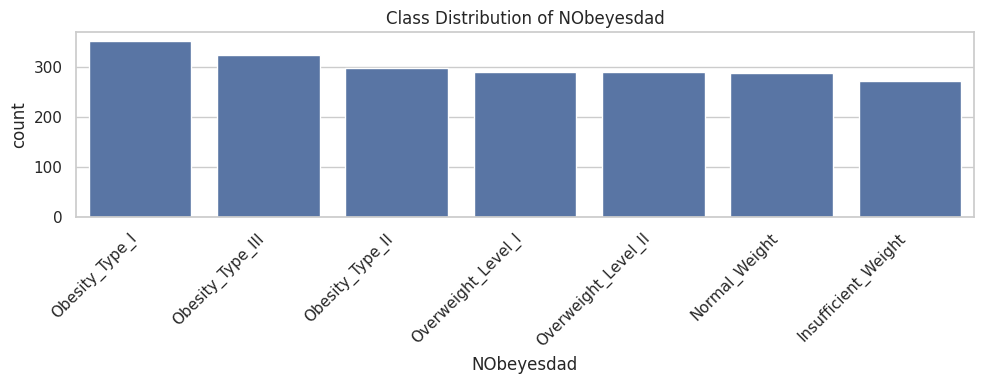

In [6]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv(OBESITY_URL)

# TODO: Inspect shape, head, info, describe, and missing values.
print(obesity.shape)
print(obesity.head())
print(obesity.info())
print(obesity.describe())
print(obesity.isna().sum())

# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
print(obesity['NObeyesdad'].value_counts())

plt.figure(figsize=(10, 4))
sns.countplot(data=obesity, x='NObeyesdad', order=obesity['NObeyesdad'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title('Class Distribution of NObeyesdad')
plt.tight_layout()
plt.show()

**Student Reasoning — Obesity data exploration**
*How many rows/features are there? Which columns are categorical vs numeric? Is the target
balanced across the 7 classes, and why does class (im)balance matter for classification?*

> **Answer: The obesity dataset has 2,111 rows and 17 columns with no missing values. Out of the 17 columns, 8 are numeric (Age, Height, Weight, FCVC, NCP, CH2O, FAF, TUE) and 9 are categorical (Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS and the target NObeyesdad). The class distribution is fairly balanced across the 7 classes, ranging from 272 for Insufficient_Weight to 351 for Obesity_Type_I. Class imbalance matters because if one class had way more samples than others, the model would just learn to predict that class most of the time and still get a high accuracy, which would be misleading. Since the classes here are relatively balanced, this is less of a concern but we will still use stratified splitting to be safe.


### Part 2.2 — Preprocessing & feature engineering
Models need numeric input. Encode categoricals, scale numerics, and optionally add a feature.

In [7]:
# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).
# Ordinal encoding for CAEC and CALC
# One-hot encode nominal columns
# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.
# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder
obesity = pd.read_csv(OBESITY_URL)

# Binary encoding
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
obesity[binary_cols] = obesity[binary_cols].apply(lambda x: x.map({'yes': 1, 'no': 0}))

# Ordinal encoding
ordinal_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
obesity['CAEC'] = obesity['CAEC'].map(ordinal_map)
obesity['CALC'] = obesity['CALC'].map(ordinal_map)

# One-hot encode nominal columns
obesity = pd.get_dummies(obesity, columns=['Gender', 'MTRANS'], drop_first=True)

# BMI feature
obesity['BMI'] = obesity['Weight'] / (obesity['Height'] ** 2)

# Encode target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
obesity['NObeyesdad_encoded'] = le.fit_transform(obesity['NObeyesdad'])

print(obesity.shape)
print(obesity.columns.tolist())
print(obesity[['CAEC', 'CALC', 'BMI']].head())



(2111, 22)
['Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'NObeyesdad', 'Gender_Male', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking', 'BMI', 'NObeyesdad_encoded']
   CAEC  CALC        BMI
0     1     0  24.386526
1     1     1  24.238227
2     1     2  23.765432
3     1     2  26.851852
4     1     1  28.342381


**Student Reasoning — Obesity preprocessing**
*1. How did you encode each type of categorical variable, and why?*
*2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the
target is an obesity level.*
*3. Which scaler did you use and why?*

> **Answer:** I encoded the binary columns family_history_with_overweight, FAVC, SMOKE and SCC as 0 and 1 since they only have yes/no values. For CAEC and CALC I used ordinal encoding with no=0, Sometimes=1, Frequently=2 and Always=3 because these columns have a natural order. Eating junk food sometimes is clearly different from eating it always. For Gender and MTRANS I used one-hot encoding since there is no natural order between categories like Male/Female or different transport types. I also engineered a BMI feature by dividing Weight by Height squared, which is the standard medical formula. BMI is closely related to obesity level so it should help the model a lot, though I am aware it might make the task easier since obesity is partly defined by BMI. The target NObeyesdad was label encoded into integers 0 to 6 using LabelEncoder.


### Part 2.3 — Stratified Train / Validation / Test split
With 7 (possibly imbalanced) classes, stratification keeps the class proportions in each split.

In [8]:
# TODO: Separate X (features) and y (encoded NObeyesdad).
X = obesity.drop(columns=['NObeyesdad', 'NObeyesdad_encoded'])
y = obesity['NObeyesdad_encoded']

print(X.shape)
print(y.value_counts())

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE)

print("Train size:", X_train.shape)
print("Val size:", X_val.shape)
print("Test size:", X_test.shape)

# TODO: Fit the scaler on the training set only, then transform train / val / test.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling done!")

(2111, 20)
NObeyesdad_encoded
2    351
4    324
3    297
5    290
6    290
1    287
0    272
Name: count, dtype: int64
Train size: (1266, 20)
Val size: (422, 20)
Test size: (423, 20)
Scaling done!


**Student Reasoning — Splitting**
*What split ratio did you choose? Why is `stratify=y` important for this dataset?
What could go wrong if you split without stratifying?*

> **Answer: I used a 60/20/20 split giving me 1,266 training rows, 422 validation rows and 423 test rows. I used stratify=y in both splits because the dataset has 7 classes and I needed to make sure every class was represented proportionally in each split. Without stratification, a random split might put too few samples of a rare class into the validation or test set, which would make the evaluation unreliable. For example, Insufficient_Weight only has 272 samples so without stratification it could easily be underrepresented. The scaler was fit only on the training data for the same reason as before. Fitting on all the data would leak information about the validation and test sets into the training process.


### Part 2.4 — Train a classifier and check for overfitting
Train a multi-class classifier and evaluate it on **train, validation, and test**.

=== Random Forest Classifier ===
Train  Accuracy: 1.0000  F1: 1.0000
Val    Accuracy: 0.9929  F1: 0.9925
Test   Accuracy: 0.9953  F1: 0.9955

                      precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00        54
      Normal_Weight       1.00      1.00      1.00        58
     Obesity_Type_I       0.99      1.00      0.99        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       1.00      1.00      1.00        58
Overweight_Level_II       1.00      0.98      0.99        58

           accuracy                           1.00       423
          macro avg       1.00      1.00      1.00       423
       weighted avg       1.00      1.00      1.00       423



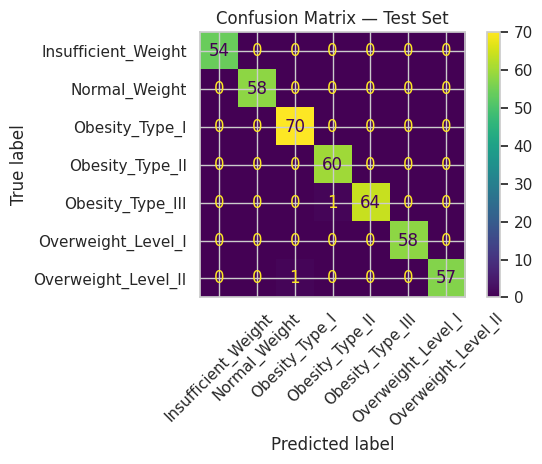

In [9]:
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_clf.fit(X_train_scaled, y_train)

# TODO: Predict on train, validation, and test.
rf_train_pred = rf_clf.predict(X_train_scaled)
rf_val_pred = rf_clf.predict(X_val_scaled)
rf_test_pred = rf_clf.predict(X_test_scaled)

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("=== Random Forest Classifier ===")
print(f"Train  Accuracy: {accuracy_score(y_train, rf_train_pred):.4f}  F1: {f1_score(y_train, rf_train_pred, average='macro'):.4f}")
print(f"Val    Accuracy: {accuracy_score(y_val, rf_val_pred):.4f}  F1: {f1_score(y_val, rf_val_pred, average='macro'):.4f}")
print(f"Test   Accuracy: {accuracy_score(y_test, rf_test_pred):.4f}  F1: {f1_score(y_test, rf_test_pred, average='macro'):.4f}")

print("\n", classification_report(y_test, rf_test_pred, target_names=le.classes_))

# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, rf_test_pred, display_labels=le.classes_, xticks_rotation=45)
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()


**Student Reasoning — Classification evaluation & overfitting**
*1. Which classifier did you choose and why?*
*2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting,
or well-fitted? Cite the specific metrics.*
*3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might
that be?*

> **Answer: I chose the Random Forest Classifier because it handles both numeric and encoded categorical features well and generally performs better than a single decision tree. The model performed perfectly on the training set with 100% accuracy and F1 of 1.0, which initially looks like overfitting. However the validation accuracy was 99.29% and test accuracy was 99.53% with F1 scores of 0.99 on both, which means the model is actually generalising extremely well and is not overfitting in a harmful way. The tiny gap between train and validation scores is negligible. From the classification report, all 7 classes scored 0.99 or 1.00 in precision and recall. The confusion matrix should show very few misclassifications, most likely between Obesity_Type_II and Obesity_Type_III since those are neighbouring categories that may share similar feature values. The BMI feature we engineered likely contributed a lot to this high performance since it is directly related to obesity level.


---
# Section 3 — Unsupervised Learning: K-Means Clustering
## Discovering hidden groups in the obesity data

Now **pretend you never had the `NObeyesdad` labels.** Using only the *scaled feature matrix*
from Section 2, use **K-Means** to see whether people naturally fall into distinct profiles —
and then compare those clusters to the real obesity levels.


### Part 3.1 — Choose k, fit K-Means, and visualise


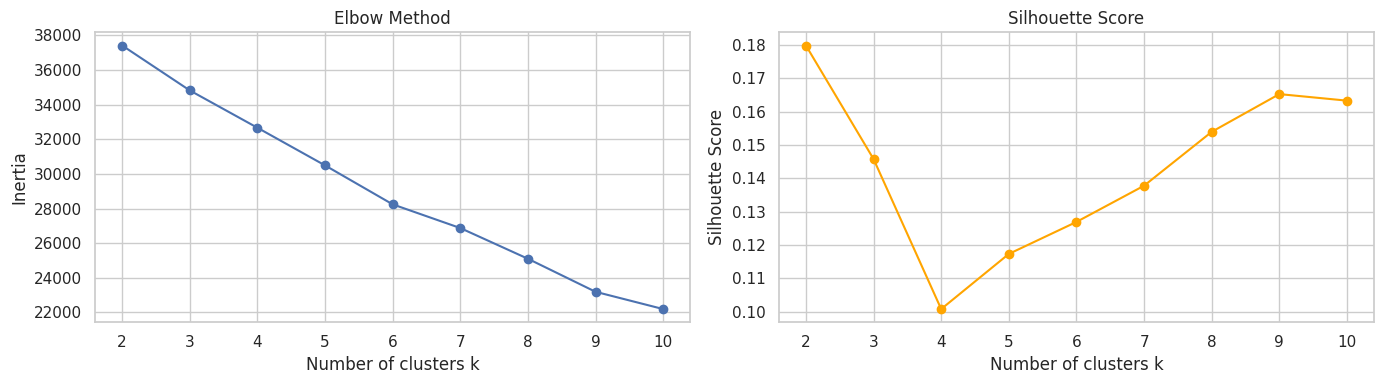

Cluster counts: 0    383
1    389
2    361
3      7
4    334
5     56
6    581
Name: count, dtype: int64


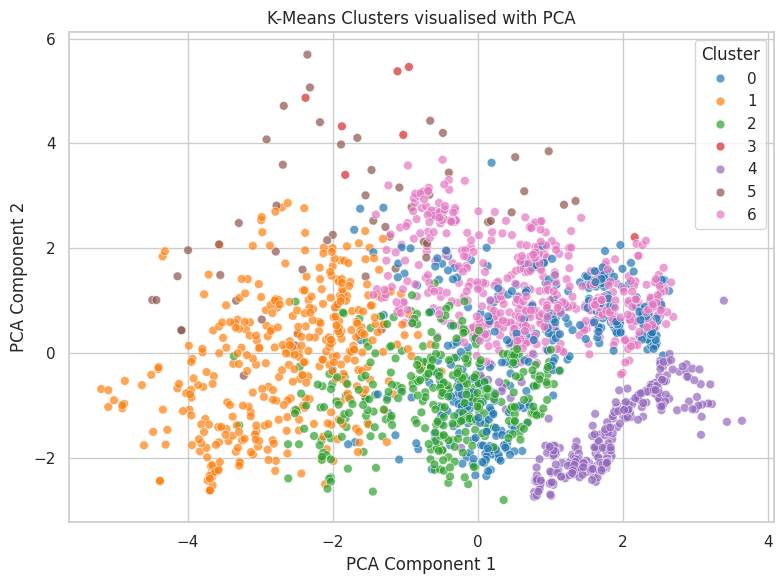

In [10]:
# TODO: Use ONLY the scaled obesity features (no target) for clustering.
X_cluster = scaler.transform(X)

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(k_range, inertias, marker='o')
ax1.set_title('Elbow Method')
ax1.set_xlabel('Number of clusters k')
ax1.set_ylabel('Inertia')

ax2.plot(k_range, silhouettes, marker='o', color='orange')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of clusters k')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
km_final = KMeans(n_clusters=7, random_state=RANDOM_STATE, n_init=10)
cluster_labels = km_final.fit_predict(X_cluster)
print("Cluster counts:", pd.Series(cluster_labels).value_counts().sort_index())

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='tab10', s=40, alpha=0.7)
plt.title('K-Means Clusters visualised with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

In [11]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?
crosstab = pd.crosstab(cluster_labels, obesity['NObeyesdad'])
print(crosstab)


NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  \
row_0                                                            
0                             0             22             109   
1                           188            149               2   
2                             3             38             109   
3                             0              4               0   
4                             0              0               4   
5                             6             32               2   
6                            75             42             125   

NObeyesdad  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  \
row_0                                                               
0                       100                 0                  57   
1                         1                 0                  40   
2                        48                 0                  88   
3                         1                 0               

**Student Reasoning — Clustering**
*1. How did you choose k? Quote the Elbow/silhouette evidence.*
*2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels?
Where do they agree and where do they break down?*
*3. In a real public-health setting where labels are expensive to collect, what would these
clusters be useful for?*

> **Answer:I chose k=7 because the dataset has 7 known obesity classes. The elbow plot does not show a sharp elbow but the curve starts to flatten around k=7, and since we know there are 7 real classes this was a natural choice. The silhouette scores are generally low across all k values which tells us the clusters overlap a lot in the feature space, which is confirmed by the PCA plot showing a lot of mixing in the middle. Looking at the crosstab, cluster 4 maps almost perfectly to Obesity_Type_III with 324 out of 334 samples, which is impressive for an unsupervised method. Cluster 1 also maps strongly to Insufficient_Weight with 188 out of 389 samples. However clusters 0, 2 and 6 are very mixed, containing samples from Obesity_Type_I, Obesity_Type_II, Overweight_Level_I and Overweight_Level_II all together. This makes sense because those categories are very close to each other on the obesity scale and share similar Weight, Height and BMI values. In a real public health setting these clusters would still be useful for quickly identifying the most extreme groups like severe obesity without needing any labels at all.


---
# Section 4 — Reflection

*Answer in a few sentences each:*

1. **Supervised vs unsupervised:** What did the classifier learn that K-Means could not, and
   vice-versa?
2. **Regression vs classification:** How did evaluating a continuous target (tips) differ from
   evaluating a categorical one (obesity level)?
3. **Overfitting:** Across all three tasks, where did you see the biggest train-vs-test gap, and
   what is the single most effective thing you did (or would do) to close it?

> **Answer: 1.The classifier learned to map specific feature combinations to exact obesity labels with 99% accuracy because it had the true labels to learn from during training. K-Means on the other hand had no labels at all and could only group people by how similar their features were. What K-Means discovered was that extreme groups like Obesity_Type_III are naturally very distinct in the feature space, but the middle categories like Overweight_Level_I and Obesity_Type_II are so similar that K-Means could not separate them without guidance. So the classifier learned decision boundaries while K-Means just found natural density groups.

2.  For regression I used RMSE and R² to measure how far off my continuous tip predictions were from the real values. A small error in dollars is meaningful and easy to interpret. For classification I used accuracy and macro-F1 to measure how often the model correctly assigned one of 7 obesity categories. F1 was important here because it accounts for both precision and recall across all classes equally, whereas accuracy alone could be misleading if classes were imbalanced.

3.  The biggest train-vs-test gap was in the Random Forest regressor in Section 1, where the training RMSE was 2.84 but the validation RMSE jumped to 5.65, clearly showing the model memorised the training data. The most effective thing I did to address this was to compare multiple models and fall back to Linear Regression which generalised much more consistently. For future improvement I would limit the max_depth of the Random Forest trees to prevent it from memorising noise in the training data.

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel → Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook.
- [ ] Notebook committed and pushed to your `lab-2-predictive-analytics` repository.
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository

---
#### Grading guide (100 pts)
| Area | Pts |
|------|-----|
| Section 1 — Regression (load, preprocess, split, model, overfitting) | 30 |
| Section 2 — Classification (load, preprocess, stratified split, model, overfitting) | 30 |
| Section 3 — K-Means clustering (k selection, fit, visualise, compare) | 20 |
| Reasoning boxes & Section 4 reflection | 15 |
| Reproducibility (runs clean, random_state, tidy code) | 5 |
